# Домашняя работа №2: Классификация при помощи CNN

В этом домашнем задании мы попрактикуемся в построении простого пайплайна обучения и имплементируем с нуля модель MobileNetV3. В качестве датасета возьмём Tiny ImageNet — это датасет, состоящий из 100 000 семплов размера 64х64 и относящихся к одному из 200 классов. Он является подвыборкой из оригинального ImageNet1K с уменьшенными картинками и меньшим количеством классов.

### План:
1. Работа с датасетом: посмотрим на сам датасет, проведём простой анализ данных, имплементируем необходимые классы для загрузки данных и работы с датасетом.
2. Имплементация MobileNetV3: реализуем два основных слоя: SqueezeExcitation и MBConv2d, затем вам будет предложено придумать свою собственную вариацию MobileNetV3, используя имплементированный MBConv2d в качестве строительного блока.
3. Построение пайплайна обучения и тренировка: вы построите простой пайплайн обучения и обучите вашу вариацию MobileNetV3 на Tiny ImageNet. Результат загрузите в LMS для тестирования на приватном датасете.

Импортируем все необходимые нам библиотеки.

In [ ]:
import io
from typing import Union, Callable, Optional

import torch
import torch.nn as nn
import torchvision as tv
import torchvision.transforms.v2 as transforms
import pandas as pd
import numpy as np
import numpy.typing as npt
import PIL.Image as Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

## Часть 1. Работа с датасетом

В этом задании будем работать с датасетом Tiny ImageNet. Его можно скачать с HuggingFace: https://huggingface.co/datasets/zh-plus/tiny-imagenet/tree/main/data. Использовать будем только train-часть. Перед тем как приступать к обучению моделей, полезно провести хотя бы минимальный анализ датасета: количество данных, количество и сбалансированность классов, размеры картинок и одинаковы ли они во всём датасете. В данном случае с этой информацией можно ознакомиться в карточке датасета, однако чуть позже мы покажем, что некоторую важную информацию всё же понадобится получить самостоятельно.

Для начала прочитаем данные и посмотрим, из чего они состоят. Они хранятся в формате .parquet, и для чтения воспользуемся функцией `read_parquet` из `pandas` с 'fastparquet'-бэкендом.

In [ ]:
data_path = None # замените на путь до .parquet-файла с train-частью датасета
df = pd.read_parquet(data_path, engine='fastparquet')
df.head()

Видим, что датасет состоит из трёх колонок: label (класс картинки), image.bytes (картинка в виде байт-массива), image.path. Последняя колонка нам не нужна, поэтому можем дропнуть её. Затем загрузим все картинки и посмотрим на одну из них, чтобы проверить правильность загрузки.

In [ ]:
df.drop(columns=['image.path'], inplace=True)
df.head()

Реализуйте функцию для чтения картинки по строке из DataFrame, содержащего данные из Tiny ImageNet. В столбце image.bytes датафрейма хранятся последовательности байтов, для работы с ними воспользуйтесь функциями из библиотеки io. Для получения картинки используйте библиотеку pillow.

Готовую функцию загрузите в LMS для автоматической проверки.

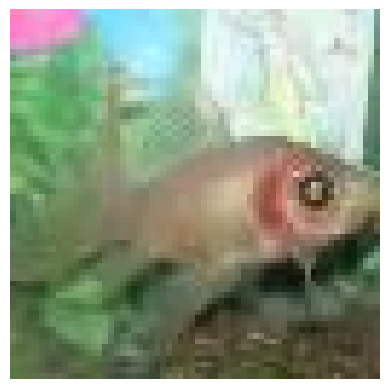

In [ ]:
def read_image(row: pd.Series) -> Image.Image:
    image = ...
    return image

all_images = [read_image(row) for i, row in df.iterrows()]

assert len(all_images) == len(df), "Не все картинки были считаны"

plt.imshow(all_images[0])
plt.axis('off')
plt.show()

Отлично! Теперь проверим размеры и форматы картинок, одинаковы ли они между собой.

In [ ]:
print("Общее число картинок:", len(all_images))

print("Количество картинок одинакового размера:", ...) # Посчитайте количество картинок с пространственным размером, равным 64х64, эту информацию можно получить через аттрибут size
print("Количество картинок в RGB:", ...) # Посчитайте число картинок в цветовом пространстве RGB, для этого используйте mode
print("Цветовые пространства картинок в датасете:", ...) # Примените np.unique к списку mode всех картинок, для того чтобы найти все цветовые пространства, встречающиеся в датасете

Как видим, все картинки, действительно, равны по размеру, но при этом часть из них не в RGB, а в Grayscale, т.е. у картинок отличаются цветовые пространства, и это критично для обучения сети, поскольку может отличаться число каналов, а также информация внутри них. В данном случае таких картинок не особо много, поэтому можно будет конвертировать их в RGB и работать с ними, как с остальными RGB-картинками. В LMS отправьте количество Grayscale-картинок.

Давайте теперь имплементируем класс датасета, который будем в дальнейшем использовать для обучения нашей модели. Метод __getitem__ должен получить строку датафрейма с индексом idx и выдать лежащую там пару (картинка, лейбл). Не забудьте применить self.transform к картинке, dtype для лейбла должен быть torch.long.

Имплементацию отправьте в LMS для проверки.

In [ ]:
class TinyImageNetDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform: Callable):
        super().__init__()

        self._data = df
        self.transform = transform

    def __len__(self) -> int:
        return len(self._data)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        sample = ... # Возьмите нужную строку из датафрейма по индексу

        image = ... # Считайте картинку, проверьте, подана ли она в RGB-формате, если нет, то конвертируйте в него. В конце примените self.transform к картинке
        label = ... # Оберните label в тензор с torch.long-типом данных

        return image, label

Теперь разобьём наши данные на train- и validation-части. Здесь важно разбить датасет, сохраняя сбалансированность классов. Напишите функцию stratified_train_val_split , которая разобьёт датасет на train- и validation-части с учётом баланса классов. Не используйте готовые функции из других библиотек.

Загрузите вашу имплементацию в LMS.

In [ ]:
def stratified_train_val_split(df: pd.DataFrame, train_share: float, seed: int = 42) -> tuple[pd.DataFrame, pd.DataFrame]:
    np.random.seed(seed)

    label_counts = ... # Посчитайте число каждого из лейблов в датасете с помощью метода value_counts
    train_counts = (label_counts * train_share).round().astype(int) # Столько лейблов каждого класса мы ожидаем в будущей train-части датасета

    train_indices, val_indices = [], []
    for label in label_counts.index:
        class_indices = ... # Получите индексы для текущего класса

        shuffled_indices = ... # Перемешайте их с помощью функции permutation из numpy

        n_train = train_counts[label]
        train_indices.extend(shuffled_indices[:n_train])
        val_indices.extend(shuffled_indices[n_train:])

    train_df = df.loc[train_indices].copy()
    val_df = df.loc[val_indices].copy()

    train_df.sort_index(inplace=True)
    val_df.sort_index(inplace=True)

    return train_df, val_df

Отлично! Теперь мы реализовали все необходимые функции для работы с датасетом, которые пригодятся при построении нашего пайплайна обучения.

## Часть 2. MobileNetV3-имплементация

В рамках этого домашнего задания предлагаем реализовать архитектуру MobileNetV3 с нуля. Умение имплементировать архитектуру новой модели по статье — это очень полезный и зачастую необходимый скилл для CV-инженера, работающего с нейронными сетями. Мы несколько упростим задачу: во-первых, эта архитектура и её предшественники уже подробно разбирались в лекциях; во-вторых, мы предоставим краткую выжимку информации о каждом слое и его визуализацию. Для интересующихся студентов также советуем почитать оригинальную статью: https://arxiv.org/abs/1905.02244. Мы сфокусируемся на реализации двух ключевых слоёв — Squeeze Excitation и Mobile Bottleneck Convolution (MBConv), — а затем предложим вам самостоятельно выбрать композицию блоков и построить свою вариацию MobileNetV3. Приступим.

Начнём с имплементации Squeeze Excitation, в статьях его также иногда называют Channel Attention, поскольку механизм работы слоя — адаптивное взвешивание каналов входного тензора — очень похож на attention, с которым вы познакомитесь позднее.

![squeeze-excitation](https://drive.google.com/uc?export=view&id=1H0Cm7oTwk68trXwGPeMYyL9XBeJnmU-W)

In [ ]:
# Реализуйте SqueezeExcitation-модуль

class SqueezeExcitation(nn.Module):
    def __init__(self, in_channels: int, squeeze_rate: int) -> None:
        super().__init__()

        self.se_block = ...

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return ...

Отлично! Загрузите вашу имплементацию с LMS.

Теперь займёмся реализацией MBConv. Ниже представлена структура блока:

![image.png](https://drive.google.com/uc?export=view&id=1CNTaXmLLFLAnZlEV1Qd8DTv2jn-WeEWM)

Здесь NL — нелинейная активация (в случае MobileNetV3 — ReLU6 или Hardswish), Dwise — depthwise-свёртка.

In [ ]:
class MBConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, exp_channels: int, kernel_size: Union[int, tuple[int, int]],
                 padding: Union[int, tuple[int, int]], stride: Union[int, tuple[int, int]], non_linearity: str = 'RE',
                 se_block: bool = True, squeeze_rate: int = 16) -> None:
        super().__init__()

        self.non_linearity_bank = {'RE': nn.ReLU6, 'HS': nn.Hardswish}

        self.use_skip_connection = stride != 2 and in_channels == out_channels

        self.layers = []
        
        # Расширяем количество входных каналов, если нужно
        if exp_channels != in_channels:
            ...

        ...

        self.layers = nn.Sequential(*self.layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.layers(x)
        # Если пространственный размер входного тензора не меняется, то прибавляем скип
        if self.use_skip_connection:
            out = ...
        return out

Загрузите результат в LMS.

Осталось построить непосредственно саму сеть MobileNetV3. Предлагаем вам самостоятельно поэкспериментировать над композицией сети, ориентируйтесь на компоновки из лекций и статьи в качестве источника идей. Однако держите в голове, что оригинальная MobileNetV3 тренировалась на ImageNet-1K с размером картинок 224х224, а у нас они размера 64х64. В качестве некоторой интуиции по выбору количества слоёв и их гиперпараметров предлагаем контролировать receptive field — модели.

Receptive field — это размер области во входном изображении, которую «видит» каждый нейрон в определённом слое сети. Существует эмпирическая формула его подсчёта, выведенная в статье [Computing Receptive Fields of Convolutional Neural Networks](https://distill.pub/2019/computing-receptive-fields/), приведём её для самого глубокого «нулевого» слоя (эквивалентно receptive field'у всей модели):

$ r_0 = \sum_{l=1}^L \big( (k_l - 1) \prod_{i=1}^{l-1} s_i \big) + 1, $

где $r_0$ — receptive field сети, $k_l$ — размер ядра *l*-го слоя, $s_i$ — stride *i*-го слоя.

Также мы введём дополнительное ограничение на размер и вычислительную сложность сети (в FLOPs), их вы можете мерить через функцию `summary` из библиотеки `torchinfo`.

In [ ]:
class MobileNetV3(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()

        self.in_channels = in_channels

        self.stem = ...

        self.feature_extractor = ...

        self.classifier = ...

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.feature_extractor(x)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.forward_features(x)
        x = self.classifier(x)
        return x

model = MobileNetV3(3, 200)
model_summary = summary(model, input_size=(1,3,64,64), verbose=True)

assert model_summary.total_params <= 1.5e6, "Слишком много параметров, уменьшите сеть"
assert model_summary.total_mult_adds <= 1e8, "Слишком высокая вычислительная сложность, оптимизируйте сеть"

## Часть 3. Тренировка сети

Постройте пайплайн тренировки сети, можете адаптировать пайплайн из практики.

In [ ]:
def run_epoch(model: nn.Module, loader: DataLoader, criterion: Callable,\
              optimizer: Optional[torch.optim.Optimizer] = None, device: torch.device = torch.device("cpu")) -> torch.Tensor:
    ...

    return loss_epoch, acc_epoch

def train(model: nn.Module, n_epochs: int, train_loader: DataLoader, criterion: Callable, optimizer: torch.optim.Optimizer,\
          val_loader: Optional[DataLoader] = None, val_freq: int = 10, device: torch.device = torch.device("cpu")) -> nn.Module:
    enable_validation = val_loader is not None

    for epoch in range(n_epochs):
        model.train()
        train_loss_epoch, train_acc_epoch = run_epoch(model, train_loader, criterion, optimizer, device)

        print(f"Epoch {epoch+1}:")
        print(f"Train loss: {train_loss_epoch} | Train acc: {train_acc_epoch * 100}%")

        if enable_validation and epoch % val_freq == 0:
            model.eval()
            with torch.no_grad():
                val_loss_epoch, val_acc_epoch = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

            print(f"Val loss: {val_loss_epoch} | Val acc: {val_acc_epoch * 100}%")

    return model

In [ ]:
train_df, val_df = stratified_train_val_split(df, train_share=0.9, seed=42)

transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ToDtype(dtype=torch.float32, scale=True)
])

train_dataset, val_dataset = TinyImageNetDataset(train_df, transform), TinyImageNetDataset(val_df, transform)

# подберите размер батча
train_loader, val_loader = DataLoader(train_dataset, batch_size=..., shuffle=True, pin_memory=True, drop_last=True),\
                           DataLoader(val_dataset, batch_size=..., pin_memory=True, shuffle=False)

n_epochs = ... # число эпох
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MobileNetV3(3, 200)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=..., foreach=False, fused=True) # подберите learning rate

model = train(model, n_epochs, train_loader, criterion, optimizer, val_loader, val_freq=1, device=device)

In [ ]:
torch.save(model.state_dict(), "model.pth")

Загрузите в LMS вашу реализацию MobileNetV3 и чекпоинт к нему для проверки на приватной части датасета.

В этом домашнем задании мы поработали с датасетом Tiny ImageNet, реализовали MobileNetV3 с нуля и построили простой пайплайн обучения. Пока что модель имеет относительно низкие значения по метрике качества, но в следующем уроке вы ознакомитесь с более продвинутыми пайплайнами обучения и сможете улучшить результат.